In [ ]:
"""
marketgan.py — Full MarketGAN pipeline
========================================
Builds on top of TCN.py (GeneratorTCN, DiscriminatorTCN, ResidualGeneratorTCN).

Sections:
  1. Config
  2. Data loading & preprocessing  (returns + macro covariates)
  3. Rolling OLS  →  alpha_hat, beta_hat, sigma_hat
  4. Dataset / DataLoader
  5. MarketGenerator  (TCN conditioned on macro + latent noise)
  6. MarketCritic     (TCN conditioned on macro)
  7. WGAN-GP training loop

Macro covariates (dy=8, from macro/macro_conditioning_features.csv):
  initial_jobless_claims, crb_commodity_index, cdx_ig, usd_3m_libor,
  fed_funds, usd_2y_swap, USSWAP10 CMPN Curncy, cdx_hy

Reference: Huh et al. (2026), arXiv:2601.17773
"""

from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


# Import TCN building blocks
THIS_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

from TCN import GeneratorTCN, DiscriminatorTCN, ResidualGeneratorTCN



# 1. Config
@dataclass
class MarketGANConfig:
    # --- paths ---
    returns_path: Path = Path("data/all_assets_log_returns.csv")
    macro_path:   Path = Path("data/macro/macro_conditioning_features.csv")

    # --- factor model ---
    num_factors:    int = 1    # 1 = market proxy; swap for FF3/FF5 later
    rolling_window: int = 252  # 1-year rolling OLS window

    # --- TCN architecture (paper Appendix B) ---
    num_blocks:         int   = 6
    generator_channels: int   = 80
    critic_channels:    int   = 160
    kernel_size:        int   = 2
    dilation_base:      int   = 2
    dropout:            float = 0.10
    latent_dim:         int   = 10   # dz  (paper §3.1 fn.7)

    # --- sequence lengths ---
    # RFS = 1 + 2*(k-1)*(D^L-1)/(D-1) = 127  for k=2, D=2, L=6
    # warmup = RFS - 1 = 126
    target_horizon: int = 252 * 4   # usable steps per window

    @property
    def warmup(self) -> int:
        return 1 + 2 * (self.kernel_size - 1) * (
            self.dilation_base ** self.num_blocks - 1
        ) // (self.dilation_base - 1) - 1   # = 126

    @property
    def total_seq_len(self) -> int:
        return self.target_horizon + self.warmup

    # --- training ---
    batch_size:   int   = 16
    critic_steps: int   = 5
    lr_generator: float = 1e-3
    lr_critic:    float = 1e-3
    adam_betas:   Tuple[float, float] = (0.0, 0.9)
    gp_lambda:    float = 10.0
    num_epochs:   int   = 200
    log_every:    int   = 10

    sigma_floor: float = 1e-6
    seed:        int   = 42
    device:      str   = "cuda" if torch.cuda.is_available() else "cpu"



# 2. Data loading & preprocessing


def load_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [str(c).strip() for c in df.columns]
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").set_index("Date")
    df = df[~df.index.duplicated(keep="last")]
    return df.apply(pd.to_numeric, errors="coerce")


def load_macro(path: Path, target_index: pd.DatetimeIndex) -> pd.DataFrame:
    """
    Load macro covariates, align to returns index via ffill/bfill,
    then z-score standardise.
    """
    macro = load_csv(path).dropna(how="all")
    macro = macro.reindex(target_index).ffill().bfill().dropna(how="any")
    mu  = macro.mean()
    std = macro.std().replace(0.0, 1.0)
    return (macro - mu) / std


def build_proxy_factors(returns: pd.DataFrame, num_factors: int) -> pd.DataFrame:
    """
    Simple factor proxies from the asset universe.
      F1 : equal-weighted mean (market)
      F2 : bonds − equities
      F3 : commodities − bonds
    """
    bond_cols   = [c for c in returns.columns if c in
                   ["agg","bnd","emb","hyg","ief","lqd","mub","shy","tip","tlt"]]
    equity_cols = [c for c in returns.columns if c in
                   ["aapl","amzn","jnj","jpm","msft","nflx","nvda","tsla","v","xom"]]
    comm_cols   = [c for c in returns.columns if c in
                   ["coffee","copper","corn","crude_oil","gold",
                    "natural_gas","platinum","silver","soybeans","wheat"]]
    factors = pd.DataFrame(index=returns.index)
    factors["mkt"] = returns.mean(axis=1)
    if num_factors >= 2:
        factors["bond_minus_eq"] = (
            returns[bond_cols].mean(axis=1) - returns[equity_cols].mean(axis=1))
    if num_factors >= 3:
        factors["comm_minus_bond"] = (
            returns[comm_cols].mean(axis=1) - returns[bond_cols].mean(axis=1))
    return factors.iloc[:, :num_factors]



# 3. Rolling OLS  →  alpha_hat, beta_hat, sigma_hat


def rolling_ols(
    returns: np.ndarray,   # (T, N)
    factors: np.ndarray,   # (T, K)
    window:  int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Step s: regress returns[s:s+window] on factors[s:s+window].
    Output shapes (T-window, *):
      alpha_hat : (T-window, N)
      beta_hat  : (T-window, N, K)
      sigma_hat : (T-window, N)
    """
    T, N = returns.shape
    K    = factors.shape[1]
    steps = T - window

    alpha = np.zeros((steps, N),    dtype=np.float32)
    beta  = np.zeros((steps, N, K), dtype=np.float32)
    sigma = np.zeros((steps, N),    dtype=np.float32)

    for s in range(steps):
        R = returns[s : s + window]
        F = factors[s : s + window]
        X = np.concatenate([np.ones((window, 1)), F], axis=1)
        coeffs, _, _, _ = np.linalg.lstsq(X, R, rcond=None)
        resid = R - X @ coeffs
        dof   = max(window - (1 + K), 1)
        alpha[s] = coeffs[0]
        beta[s]  = coeffs[1:].T
        sigma[s] = np.sqrt((resid ** 2).sum(axis=0) / dof)

    return alpha, beta, sigma



# PreparedData container


@dataclass
class PreparedData:
    returns:     np.ndarray        # (T', N)
    factors:     np.ndarray        # (T', K)
    covariates:  np.ndarray        # (T', dy)
    alpha_hat:   np.ndarray        # (T', N)
    beta_hat:    np.ndarray        # (T', N, K)
    sigma_hat:   np.ndarray        # (T', N)
    asset_cols:  List[str]
    factor_cols: List[str]
    macro_cols:  List[str]
    dates:       pd.DatetimeIndex
    N:  int
    K:  int
    dy: int


def prepare_data(
    config: MarketGANConfig,
    factor_df: Optional[pd.DataFrame] = None,
) -> PreparedData:

    ret_df = load_csv(config.returns_path).dropna(how="any")

    macro_df = load_macro(config.macro_path, ret_df.index)

    if factor_df is not None:
        fac_df = factor_df.copy()
        if "Date" in fac_df.columns:
            fac_df = fac_df.set_index(pd.to_datetime(fac_df["Date"])).drop(columns=["Date"])
        fac_df = fac_df.iloc[:, :config.num_factors].reindex(ret_df.index).ffill().bfill()
    else:
        fac_df = build_proxy_factors(ret_df, config.num_factors)

    # --- align ---
    common = ret_df.index.intersection(macro_df.index).intersection(fac_df.index)
    ret_df   = ret_df.loc[common].dropna(how="any")
    macro_df = macro_df.loc[common].dropna(how="any")
    fac_df   = fac_df.loc[common].dropna(how="any")
    common   = ret_df.index.intersection(macro_df.index).intersection(fac_df.index)
    ret_df   = ret_df.loc[common]
    macro_df = macro_df.loc[common]
    fac_df   = fac_df.loc[common]

    R = ret_df.to_numpy(dtype=np.float32)
    F = fac_df.to_numpy(dtype=np.float32)
    C = macro_df.to_numpy(dtype=np.float32)
    w = config.rolling_window

    alpha, beta, sigma = rolling_ols(R, F, window=w)

    # Align: step s models r_{s+w}.
    # covariate at t is known before r_{t+1} → use C[s+w-1] for step s
    returns_al    = R[w:]
    factors_al    = F[w:]
    covariates_al = C[w - 1 : -1]
    dates_al      = ret_df.index[w:]

    return PreparedData(
        returns     = returns_al,
        factors     = factors_al,
        covariates  = covariates_al,
        alpha_hat   = alpha,
        beta_hat    = beta,
        sigma_hat   = sigma,
        asset_cols  = list(ret_df.columns),
        factor_cols = list(fac_df.columns),
        macro_cols  = list(macro_df.columns),
        dates       = dates_al,
        N  = R.shape[1],
        K  = F.shape[1],
        dy = C.shape[1],
    )



# 4. Dataset / DataLoader

class MarketGANDataset(Dataset):
    def __init__(self, data: PreparedData, total_seq_len: int):
        T = data.returns.shape[0]
        if T < total_seq_len:
            raise ValueError(
                f"Not enough aligned data: {T} steps < total_seq_len {total_seq_len}.")
        self.data      = data
        self.seq_len   = total_seq_len
        self.n_windows = T - total_seq_len + 1

    def __len__(self) -> int:
        return self.n_windows

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        sl = slice(idx, idx + self.seq_len)
        return {
            "returns":    torch.tensor(self.data.returns[sl],    dtype=torch.float32),
            "factors":    torch.tensor(self.data.factors[sl],    dtype=torch.float32),
            "covariates": torch.tensor(self.data.covariates[sl], dtype=torch.float32),
            "alpha_hat":  torch.tensor(self.data.alpha_hat[sl],  dtype=torch.float32),
            "beta_hat":   torch.tensor(self.data.beta_hat[sl],   dtype=torch.float32),
            "sigma_hat":  torch.tensor(self.data.sigma_hat[sl],  dtype=torch.float32),
        }


def make_dataloaders(
    data: PreparedData,
    config: MarketGANConfig,
    train_frac: float = 0.80,
) -> Tuple[DataLoader, DataLoader]:
    dataset = MarketGANDataset(data, config.total_seq_len)
    n_train = max(1, int(len(dataset) * train_frac))
    n_val   = len(dataset) - n_train
    train_ds, val_ds = torch.utils.data.random_split(
        dataset, [n_train, n_val],
        generator=torch.Generator().manual_seed(config.seed),
    )
    train_loader = DataLoader(
        train_ds, batch_size=config.batch_size, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(
        val_ds,   batch_size=config.batch_size, shuffle=False, drop_last=False)
    return train_loader, val_loader



# 5. MarketGenerator


class MarketGenerator(nn.Module):
    """
    r_{t+1} = α_t + β_t·F_{t+1} + σ_t ⊙ ε_{t+1}   (paper eq.1)

    α_t = α̂_t ⊙ (1 + f_α(z, y))                    (paper eq.2)
    β_t = β̂_t ⊙ (1 + f_β(z, y))
    σ_t = σ̂_t ⊙ (1 + f_σ(z, y))

    TCN input per time step: [z ∥ y]  shape (dz + dy,)
    f_α / f_β / f_σ share the GeneratorTCN backbone (80 ch).
    ε uses ResidualGeneratorTCN (all 1×1, RFS=1).
    """

    def __init__(self, N: int, K: int, dy: int, config: MarketGANConfig):
        super().__init__()
        self.N, self.K, self.dy, self.cfg = N, K, dy, config
        in_ch = config.latent_dim + dy

        self.coef_gen = GeneratorTCN(
            in_channels     = in_ch,
            out_alpha       = N,
            out_beta        = N * K,
            out_sigma       = N,
            hidden_channels = config.generator_channels,
            num_blocks      = config.num_blocks,
            kernel_size     = config.kernel_size,
            dilation_base   = config.dilation_base,
            dropout         = config.dropout,
        )
        self.res_gen = ResidualGeneratorTCN(
            in_channels     = in_ch,
            out_channels    = N,
            hidden_channels = config.generator_channels,
            num_layers      = config.num_blocks,
            dropout         = 0.0,
        )

    def _noise(self, B, T, device):
        z_c = torch.randn(B, self.cfg.latent_dim, T, device=device)
        z_r = torch.randn(B, self.cfg.latent_dim, T, device=device)
        return z_c, z_r

    def forward(
        self,
        alpha_hat:  torch.Tensor,   # (B, T, N)
        beta_hat:   torch.Tensor,   # (B, T, N, K)
        sigma_hat:  torch.Tensor,   # (B, T, N)
        factors:    torch.Tensor,   # (B, T, K)
        covariates: torch.Tensor,   # (B, T, dy)
        trim: bool = True,
    ) -> Dict[str, torch.Tensor]:
        B, T, N = alpha_hat.shape
        device  = alpha_hat.device

        z_c, z_r = self._noise(B, T, device)
        y = covariates.permute(0, 2, 1)              # (B, dy, T)

        inp_c = torch.cat([z_c, y], dim=1)           # (B, dz+dy, T)
        inp_r = torch.cat([z_r, y], dim=1)

        f_alpha, f_beta, f_sigma = self.coef_gen(inp_c)

        f_alpha = f_alpha.permute(0, 2, 1)           # (B, T, N)
        f_beta  = f_beta.permute(0, 2, 1).reshape(B, T, N, self.K)
        f_sigma = f_sigma.permute(0, 2, 1)

        alpha   = alpha_hat * (1.0 + f_alpha)
        beta    = beta_hat  * (1.0 + f_beta)
        sigma   = torch.clamp(sigma_hat * (1.0 + f_sigma), min=self.cfg.sigma_floor)
        epsilon = self.res_gen(inp_r).permute(0, 2, 1)  # (B, T, N)

        systematic = alpha + torch.einsum("btnk,btk->btn", beta, factors)
        r_gen      = systematic + sigma * epsilon

        w = self.cfg.warmup if trim else 0
        return {
            "generated_returns": r_gen[:, w:],
            "alpha":   alpha[:, w:],
            "beta":    beta[:, w:],
            "sigma":   sigma[:, w:],
            "epsilon": epsilon[:, w:],
        }



# 6. MarketCritic


class MarketCritic(nn.Module):
    """
    WGAN-GP critic. Input per time step: [r ∥ y]  (N + dy,).
    Output: scalar per sequence, no sigmoid.
    """

    def __init__(self, N: int, dy: int, config: MarketGANConfig):
        super().__init__()
        self.disc = DiscriminatorTCN(
            in_channels     = N + dy,
            hidden_channels = config.critic_channels,
            num_blocks      = config.num_blocks,
            kernel_size     = config.kernel_size,
            dilation_base   = config.dilation_base,
            dropout         = config.dropout,
        )

    def forward(self, returns: torch.Tensor, covariates: torch.Tensor) -> torch.Tensor:
        # (B, T, N+dy) → (B, N+dy, T)
        x = torch.cat([returns, covariates], dim=-1).permute(0, 2, 1)
        return self.disc(x)   # (B,)



# 7. WGAN-GP training loop


def gradient_penalty(
    critic: MarketCritic,
    real: torch.Tensor, fake: torch.Tensor,
    covariates: torch.Tensor, lam: float,
) -> torch.Tensor:
    B   = real.size(0)
    eps = torch.rand(B, 1, 1, device=real.device)
    interp = (eps * real + (1 - eps) * fake).requires_grad_(True)
    score  = critic(interp, covariates)
    grads  = torch.autograd.grad(
        outputs=score, inputs=interp,
        grad_outputs=torch.ones_like(score),
        create_graph=True, retain_graph=True,
    )[0]
    return lam * ((grads.reshape(B, -1).norm(2, dim=1) - 1) ** 2).mean()


def train(
    config: MarketGANConfig,
    factor_df: Optional[pd.DataFrame] = None,
    train_frac: float = 0.80,
) -> Tuple[MarketGenerator, MarketCritic, pd.DataFrame]:
    torch.manual_seed(config.seed)
    device = torch.device(config.device)

    print("Preparing data …")
    data = prepare_data(config, factor_df=factor_df)
    print(f"  Assets: {data.N}  Factors: {data.K}  Covariates: {data.dy}")
    print(f"  Aligned steps: {data.returns.shape[0]}")
    print(f"  Warmup: {config.warmup}  Target horizon: {config.target_horizon}")
    print(f"  Total seq len: {config.total_seq_len}")

    train_loader, val_loader = make_dataloaders(data, config, train_frac)
    print(f"  Train batches: {len(train_loader)}  Val batches: {len(val_loader)}")

    generator = MarketGenerator(data.N, data.K, data.dy, config).to(device)
    critic    = MarketCritic(data.N, data.dy, config).to(device)

    opt_G = torch.optim.Adam(generator.parameters(), lr=config.lr_generator, betas=config.adam_betas)
    opt_D = torch.optim.Adam(critic.parameters(),    lr=config.lr_critic,    betas=config.adam_betas)

    n_g = sum(p.numel() for p in generator.parameters() if p.requires_grad)
    n_d = sum(p.numel() for p in critic.parameters()    if p.requires_grad)
    print(f"  Generator params: {n_g:,}  Critic params: {n_d:,}")

    history = []
    w = config.warmup

    for epoch in tqdm(range(1, config.num_epochs + 1), desc="Training"):
        generator.train(); critic.train()
        d_losses, g_losses = [], []

        for batch in train_loader:
            batch      = {k: v.to(device) for k, v in batch.items()}
            real_t     = batch["returns"][:, w:]
            cov_t      = batch["covariates"][:, w:]

            # Critic steps
            for _ in range(config.critic_steps):
                with torch.no_grad():
                    out  = generator(
                        batch["alpha_hat"], batch["beta_hat"], batch["sigma_hat"],
                        batch["factors"], batch["covariates"], trim=True)
                fake   = out["generated_returns"].detach()
                d_real = critic(real_t, cov_t).mean()
                d_fake = critic(fake,   cov_t).mean()
                gp     = gradient_penalty(critic, real_t, fake, cov_t, config.gp_lambda)
                d_loss = d_fake - d_real + gp
                opt_D.zero_grad(); d_loss.backward(); opt_D.step()
            d_losses.append(float(d_loss.detach().cpu()))

            # Generator step
            out    = generator(
                batch["alpha_hat"], batch["beta_hat"], batch["sigma_hat"],
                batch["factors"], batch["covariates"], trim=True)
            g_loss = -critic(out["generated_returns"], cov_t).mean()
            opt_G.zero_grad(); g_loss.backward(); opt_G.step()
            g_losses.append(float(g_loss.detach().cpu()))

        # Validation
        generator.eval(); critic.eval()
        val_w = []
        with torch.no_grad():
            for batch in val_loader:
                batch  = {k: v.to(device) for k, v in batch.items()}
                real_t = batch["returns"][:, w:]
                cov_t  = batch["covariates"][:, w:]
                out    = generator(
                    batch["alpha_hat"], batch["beta_hat"], batch["sigma_hat"],
                    batch["factors"], batch["covariates"], trim=True)
                val_w.append(float(
                    (critic(real_t, cov_t).mean() - critic(out["generated_returns"], cov_t).mean()).cpu()
                ))

        row = {
            "epoch":           epoch,
            "critic_loss":     np.mean(d_losses),
            "gen_loss":        np.mean(g_losses),
            "val_wasserstein": np.mean(val_w),
        }
        history.append(row)
        if epoch % config.log_every == 0 or epoch == 1:
            print(f"Epoch {epoch:>3}/{config.num_epochs} | "
                  f"D: {row['critic_loss']:+.4f} | "
                  f"G: {row['gen_loss']:+.4f} | "
                  f"Val W: {row['val_wasserstein']:+.4f}")

    return generator, critic, pd.DataFrame(history)



c:\Users\fengy\anaconda3\envs\torch2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
cfg = MarketGANConfig(
    returns_path = Path("data/all_assets_log_returns.csv"),
    macro_path   = Path("data/macro/macro_conditioning_features.csv"),
    num_factors  = 1,
    num_epochs   = 5,
    log_every    = 1,
)

data = prepare_data(cfg)
print(f"Assets: {data.N}, Factors: {data.K}, Covariates: {data.dy}")
print(f"Aligned steps: {data.returns.shape[0]}")

Assets: 30, Factors: 1, Covariates: 8
Aligned steps: 3508


In [12]:
torch.backends.cudnn.benchmark = True
generator, critic, history = train(cfg)

Preparing data …


c:\Users\fengy\anaconda3\envs\torch2\lib\site-packages\torch\nn\utils\weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


  Assets: 30  Factors: 1  Covariates: 8
  Aligned steps: 3508
  Warmup: 126  Target horizon: 1008
  Total seq len: 1134
  Train batches: 118  Val batches: 30
  Generator params: 200,680  Critic params: 624,641


Training:  20%|██        | 1/5 [01:43<06:53, 103.27s/it]

Epoch   1/5 | D: -24962.0981 | G: +44967.9287 | Val W: +30.6049


...

Epoch   3/5 | D: -4.3713 | G: +0.3755 | Val W: +1.0140


Training:  80%|████████  | 4/5 [07:44<02:00, 120.03s/it]

Epoch   4/5 | D: -1.6586 | G: -4.7887 | Val W: +0.5312


Training: 100%|██████████| 5/5 [09:51<00:00, 118.36s/it]

Epoch   5/5 | D: -1.1001 | G: -7.9666 | Val W: +0.8889


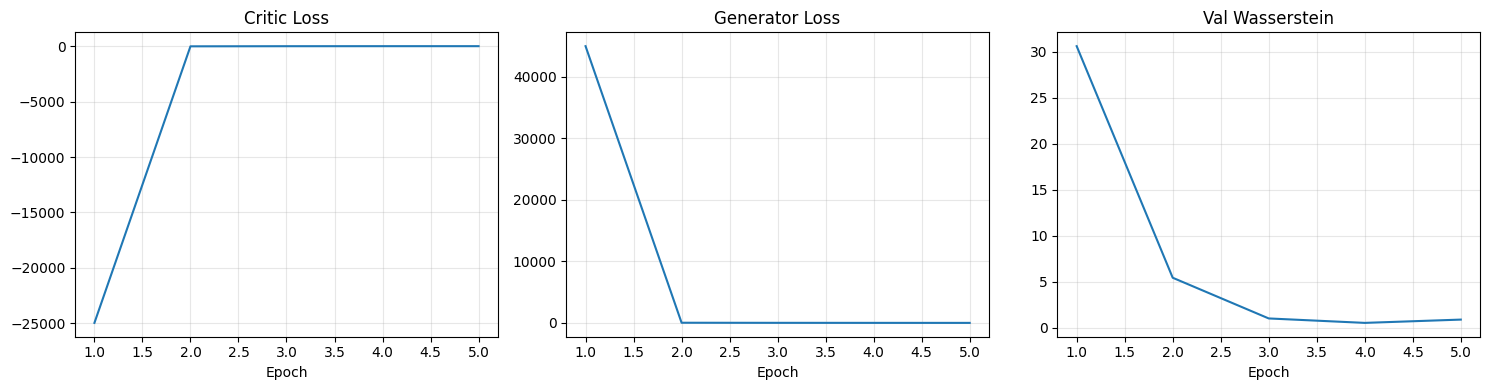

In [13]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history["epoch"], history["critic_loss"])
axes[1].plot(history["epoch"], history["gen_loss"])
axes[2].plot(history["epoch"], history["val_wasserstein"])
for ax, title in zip(axes, ["Critic Loss", "Generator Loss", "Val Wasserstein"]):
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
train_loader, _ = make_dataloaders(data, cfg)
batch = next(iter(train_loader))
batch = {k: v.to(cfg.device) for k, v in batch.items()}

generator.eval()
with torch.no_grad():
    out = generator(
        batch["alpha_hat"], batch["beta_hat"], batch["sigma_hat"],
        batch["factors"], batch["covariates"], trim=True,
    )

synthetic = out["generated_returns"][0].cpu().numpy()
df_synthetic = pd.DataFrame(synthetic, columns=data.asset_cols)
print(df_synthetic.shape)
df_synthetic.head()

(1008, 30)


,agg,bnd,emb,hyg,ief,lqd,mub,shy,tip,tlt,...,aapl,amzn,jnj,jpm,msft,nflx,nvda,tsla,v,xom
0,0.000406,-0.000247,-0.000284,-0.000716,0.001259,0.000054,-0.000067,-0.000003,-0.000135,-0.001174,...,-0.003524,-0.000283,-0.000737,0.003481,-0.005548,0.010881,-0.000835,0.000484,0.005570,0.002608
1,0.000099,-0.000268,-0.005075,-0.002641,-0.001274,0.000043,0.000042,0.000684,-0.000412,0.004286,...,-0.016993,-0.004607,-0.003119,-0.006053,0.005453,-0.008208,0.003710,-0.014219,-0.002195,0.002672
2,0.000160,0.001171,0.000076,-0.000192,0.001617,0.000100,-0.000011,0.000493,0.000369,0.001792,...,-0.000167,0.004086,-0.000490,0.002845,-0.000151,-0.010607,0.001476,0.000899,0.001631,-0.001324
3,-0.000413,0.000327,0.007047,0.005222,0.000966,0.000448,-0.000213,0.000210,0.000066,-0.001457,...,0.011773,0.032422,0.015374,-0.010537,0.004704,0.005197,0.011266,0.005194,0.009355,0.004855
4,-0.000707,0.000505,-0.006226,-0.004651,-0.002077,0.000565,-0.000191,0.000063,-0.000185,0.003656,...,0.001777,0.007555,-0.010398,-0.003319,-0.004915,-0.010983,-0.002696,-0.004093,-0.001032,0.000947


In [15]:
real = pd.DataFrame(data.returns[:cfg.target_horizon], columns=data.asset_cols)

print("mean")
print(pd.DataFrame({
    "real": real.mean(),
    "synthetic": df_synthetic.mean()
}).round(5))

print("\n vol")
print(pd.DataFrame({
    "real": real.std(),
    "synthetic": df_synthetic.std()
}).round(5))

mean
                real  synthetic
agg          0.00009    0.00006
bnd          0.00008    0.00023
emb          0.00014    0.00006
hyg          0.00011   -0.00006
ief          0.00010    0.00007
lqd          0.00015    0.00023
mub          0.00013   -0.00000
shy          0.00002    0.00006
tip         -0.00000    0.00000
tlt          0.00015    0.00023
coffee      -0.00064   -0.00142
copper      -0.00051    0.00041
corn        -0.00060    0.00041
crude_oil   -0.00111    0.00080
gold        -0.00037   -0.00006
natural_gas -0.00020    0.00056
platinum    -0.00047   -0.00042
silver      -0.00072   -0.00063
soybeans    -0.00031    0.00029
wheat       -0.00028    0.00032
aapl         0.00056   -0.00023
amzn         0.00122    0.00165
jnj          0.00051    0.00045
jpm          0.00061    0.00001
msft         0.00075    0.00088
nflx         0.00224    0.00110
nvda         0.00078    0.00153
tsla         0.00200    0.00044
v            0.00108    0.00064
xom         -0.00002    0.00015

 v